In [118]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import QuantileTransformer

%matplotlib inline
warnings.filterwarnings('ignore')
pd.set_option("display.max_columns", None)

In [119]:
df = pd.read_csv('../../data/laptop_data.csv')
df.head()

,Unnamed: 0,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832
1,1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232
2,2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000
3,3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360
4,4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080


In [120]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        1303 non-null   int64  
 1   Company           1303 non-null   object 
 2   TypeName          1303 non-null   object 
 3   Inches            1303 non-null   float64
 4   ScreenResolution  1303 non-null   object 
 5   Cpu               1303 non-null   object 
 6   Ram               1303 non-null   object 
 7   Memory            1303 non-null   object 
 8   Gpu               1303 non-null   object 
 9   OpSys             1303 non-null   object 
 10  Weight            1303 non-null   object 
 11  Price             1303 non-null   float64
dtypes: float64(2), int64(1), object(9)
memory usage: 122.3+ KB


In [121]:
df.isnull().sum()

Unnamed: 0          0
Company             0
TypeName            0
Inches              0
ScreenResolution    0
Cpu                 0
Ram                 0
Memory              0
Gpu                 0
OpSys               0
Weight              0
Price               0
dtype: int64

In [122]:
df_stats_numeric = df.describe ( )
df_stats_numeric

,Unnamed: 0,Inches,Price
count,1303.00000,1303.000000,1303.000000
mean,651.00000,15.017191,59870.042910
std,376.28801,1.426304,37243.201786
min,0.00000,10.100000,9270.720000
25%,325.50000,14.000000,31914.720000
50%,651.00000,15.600000,52054.560000
75%,976.50000,15.600000,79274.246400
max,1302.00000,18.400000,324954.720000


In [123]:
print("Checking unique values in RAM, Memory, Weight:")
print(df['Ram'].unique())
print(df['Memory'].unique())
print(df['Weight'].unique())

Checking unique values in RAM, Memory, Weight:
['8GB' '16GB' '4GB' '2GB' '12GB' '6GB' '32GB' '24GB' '64GB']
['128GB SSD' '128GB Flash Storage' '256GB SSD' '512GB SSD' '500GB HDD'
 '256GB Flash Storage' '1TB HDD' '32GB Flash Storage'
 '128GB SSD +  1TB HDD' '256GB SSD +  256GB SSD' '64GB Flash Storage'
 '256GB SSD +  1TB HDD' '256GB SSD +  2TB HDD' '32GB SSD' '2TB HDD'
 '64GB SSD' '1.0TB Hybrid' '512GB SSD +  1TB HDD' '1TB SSD'
 '256GB SSD +  500GB HDD' '128GB SSD +  2TB HDD' '512GB SSD +  512GB SSD'
 '16GB SSD' '16GB Flash Storage' '512GB SSD +  256GB SSD'
 '512GB SSD +  2TB HDD' '64GB Flash Storage +  1TB HDD' '180GB SSD'
 '1TB HDD +  1TB HDD' '32GB HDD' '1TB SSD +  1TB HDD'
 '512GB Flash Storage' '128GB HDD' '240GB SSD' '8GB SSD' '508GB Hybrid'
 '1.0TB HDD' '512GB SSD +  1.0TB Hybrid' '256GB SSD +  1.0TB Hybrid']
['1.37kg' '1.34kg' '1.86kg' '1.83kg' '2.1kg' '2.04kg' '1.3kg' '1.6kg'
 '2.2kg' '0.92kg' '1.22kg' '0.98kg' '2.5kg' '1.62kg' '1.91kg' '2.3kg'
 '1.35kg' '1.88kg' '1.89kg' '1.65

In [ ]:
DROPPING THE UNIQUE COLUMN

In [124]:
df.drop ( columns = [ 'Unnamed: 0' ] , inplace = True )
df.head()

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080


In [ ]:
EXPLORATORY DATA ANALYSIS
EXTRACTING COLUMNS

In [125]:
# Feature: TouchScreen
df['TouchScreen'] = df['ScreenResolution'].apply(lambda x: 1 if 'Touchscreen' in x else 0)

# Feature: IPS Panel
df['IPS'] = df['ScreenResolution'].apply(lambda x: 1 if 'IPS' in x else 0)

# Feature: HD or 4K Screen
df['HD_4K'] = df['ScreenResolution'].apply(lambda x: 1 if '4K' in x or 'HD' in x or 'HD+' in x else 0)

# Feature: CPU Brand
df['CPU_Brand'] = df['Cpu'].apply(lambda x: 'Intel' if 'Intel' in x else ('AMD' if 'AMD' in x else 'Other'))

# Feature: GPU Brand
df['GPU_Brand'] = df['Gpu'].apply(lambda x: 'Nvidia' if 'Nvidia' in x else ('AMD' if 'AMD' in x else 'Intel'))

# Feature: Memory Type (Improved logic)
def memory_type(mem):
    if 'HDD' in mem and 'SSD' in mem:
        return 'Hybrid'
    elif 'HDD' in mem:
        return 'HDD'
    elif 'SSD' in mem:
        return 'SSD'
    elif 'Flash' in mem:
        return 'Flash Storage'
    else:
        return 'Other'
df['Memory_Type'] = df['Memory'].apply(memory_type)

# Feature: CPU Frequency (GHz)
df['CPU_Frequency'] = df['Cpu'].str.extract(r'(\d+\.?\d*)GHz', expand=True)[0]
df['CPU_Frequency'] = pd.to_numeric(df['CPU_Frequency'], errors='coerce')

In [126]:
df_Original = df.copy()
# Feature: PPI (Pixel Density)
pixels = df['ScreenResolution'].str.extract(r'(\d+)x(\d+)')
pixels = pixels.astype('float')
df['Length'] = pixels[0]
df['Width'] = pixels[1]
df['PPI'] = ( (df['Length']**2 + df['Width']**2) ** 0.5 ) / df['Inches']

# Clean: Convert RAM and Weight to numeric
df['Ram'] = df['Ram'].str.replace('GB', '').astype('int64')
df['Weight'] = df['Weight'].str.replace('kg', '').astype('float64')

In [ ]:
DATA VISUALIZATION

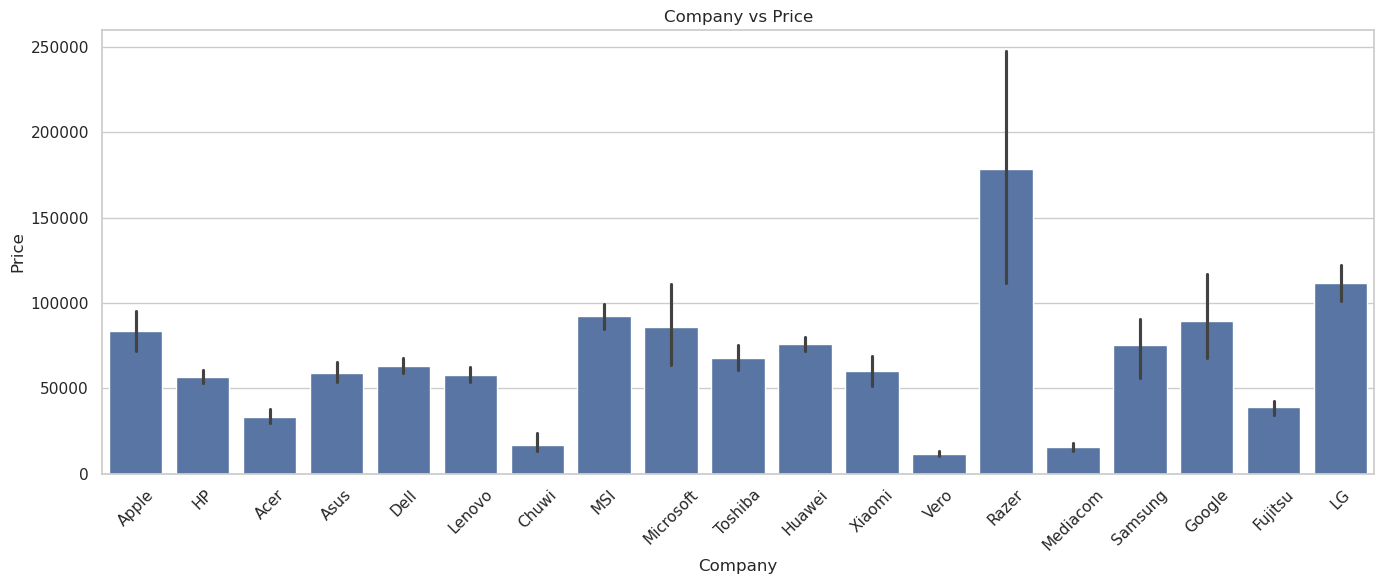

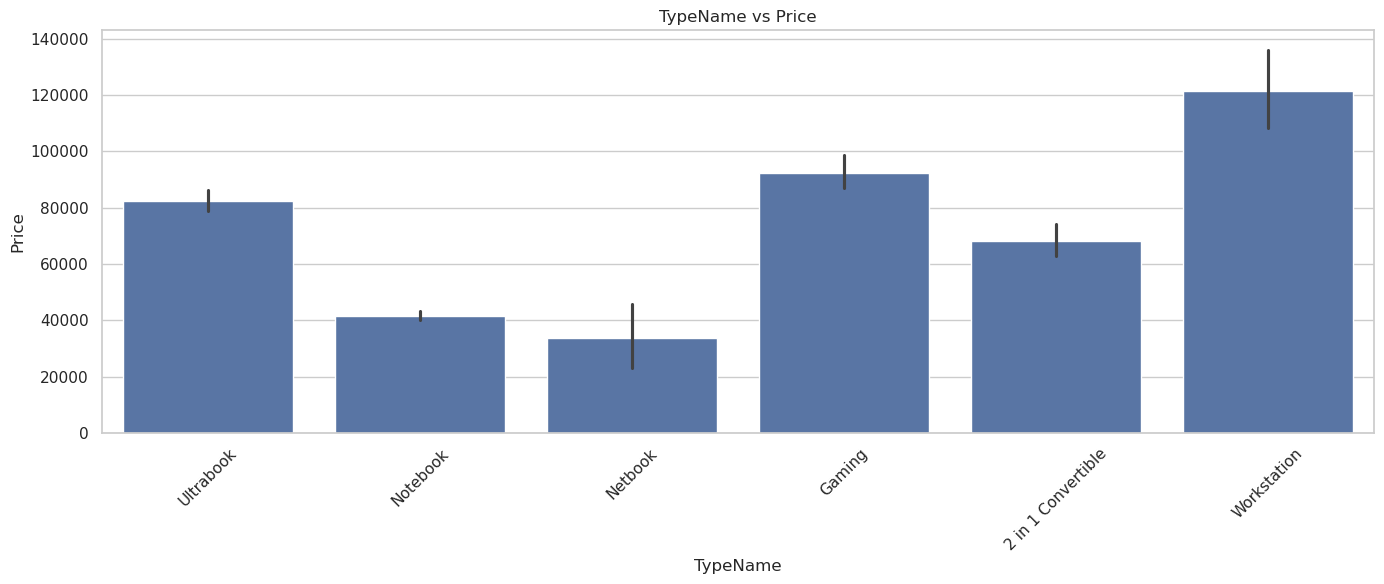

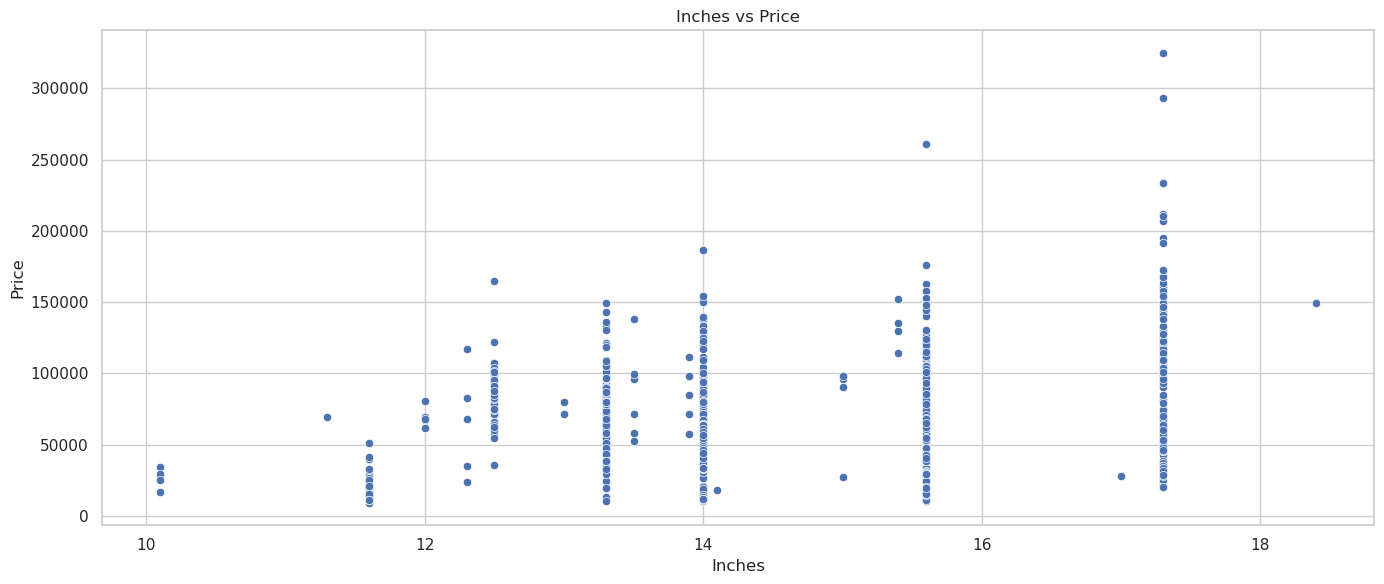

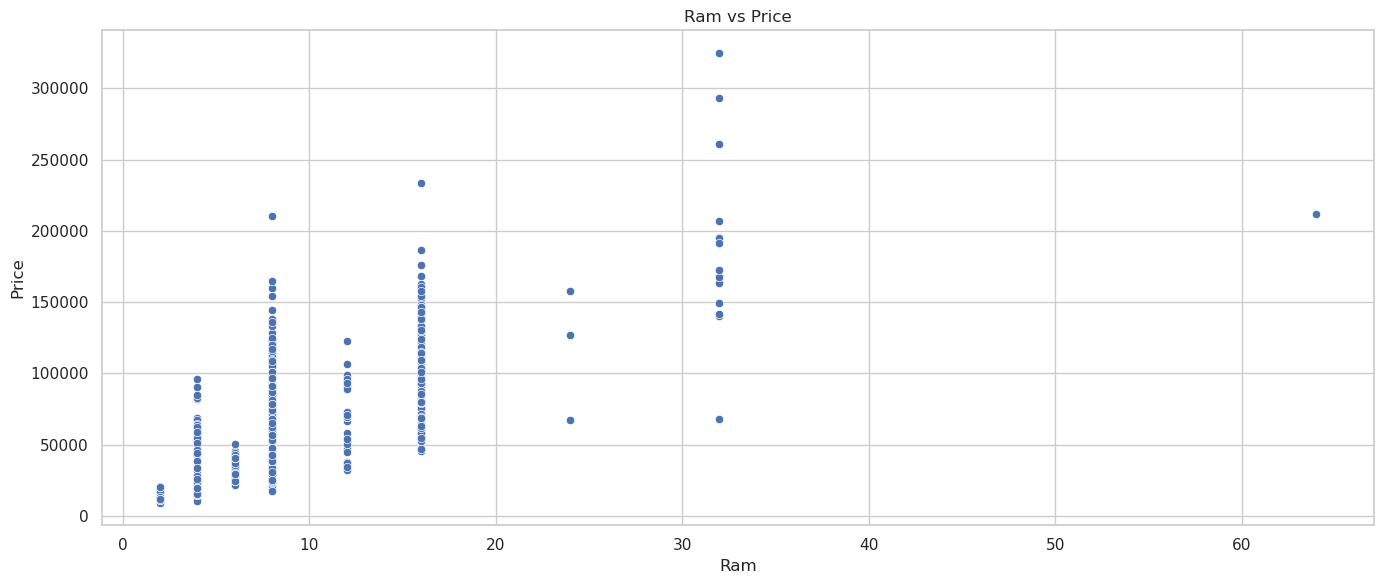

In [127]:
sns.set(style="whitegrid")
for col in ['Company', 'TypeName', 'Inches', 'Ram']:  # choose relevant cols
    plt.figure(figsize=(14,6))
    if df[col].dtype == 'object':
        sns.barplot(x=col, y='Price', data=df)
        plt.xticks(rotation=45)
    else:
        sns.scatterplot(x=col, y='Price', data=df)
    plt.title(f"{col} vs Price")
    plt.tight_layout()
    plt.show()


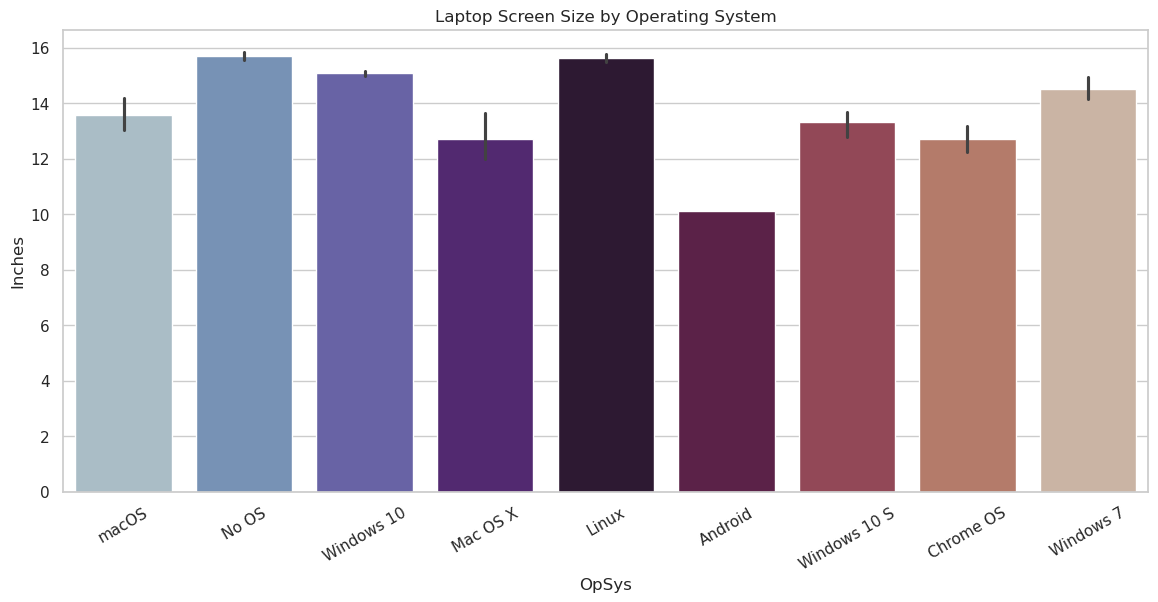

In [128]:
plt.figure(figsize=(14,6))
sns.barplot(x='OpSys', y='Inches', data=df, palette='twilight')
plt.title("Laptop Screen Size by Operating System")
plt.xticks(rotation=30)
plt.show()

<Axes: xlabel='Price', ylabel='Count'>

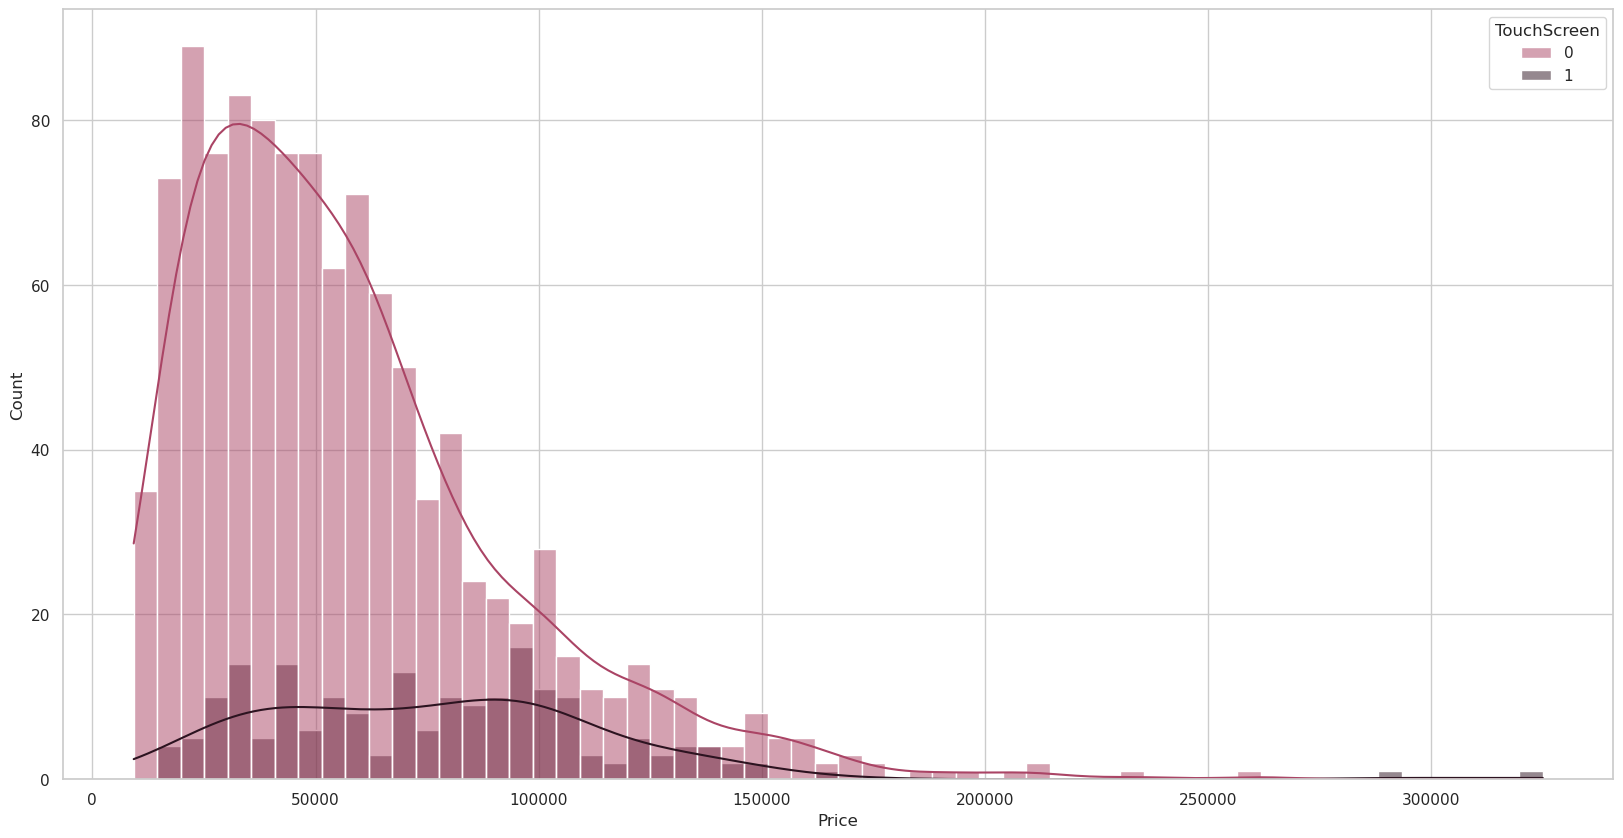

In [129]:
plt.figure(figsize=(20, 10))
sns.histplot(data=df, x='Price', kde=True, hue='TouchScreen', palette=['#AA4465', '#2C1320'], bins=60)

<Axes: xlabel='Ram', ylabel='Count'>

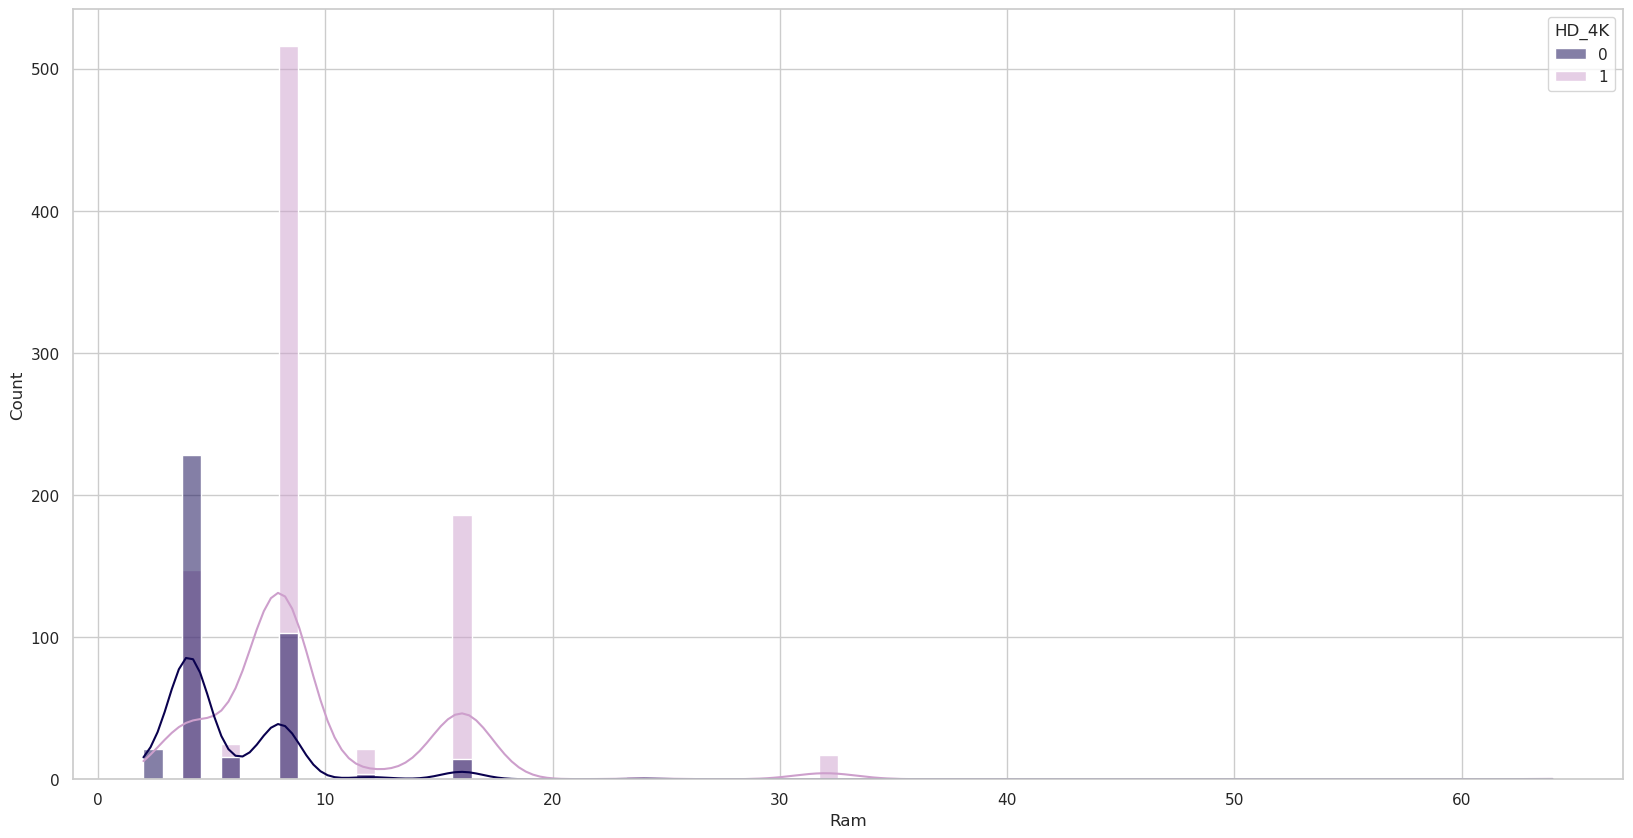

In [130]:
plt.figure(figsize=(20, 10))
df['HD_4K'] = df['ScreenResolution'].apply(lambda x: 1 if '4K' in x or 'HD' in x or 'HD+' in x else 0)
sns.histplot(data=df, x='Ram', kde=True, hue='HD_4K', palette=['#0A014F', '#CD9FCC'])

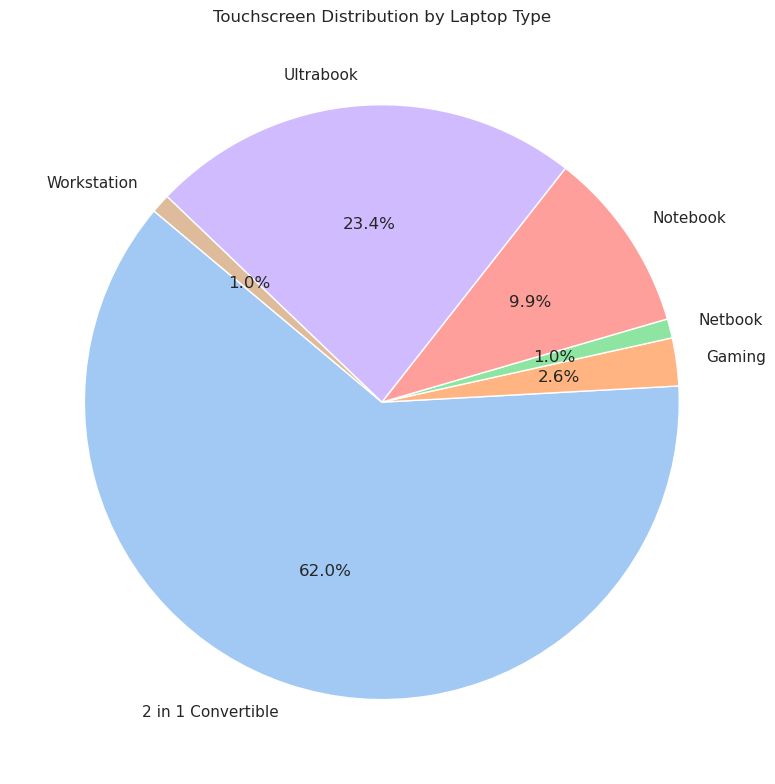

In [131]:
Data = df.groupby('TypeName')['TouchScreen'].sum().reset_index()
plt.figure(figsize=(12, 8))
colors = sns.color_palette("pastel")
plt.pie(Data['TouchScreen'], labels=Data['TypeName'], autopct='%1.1f%%', startangle=140, colors=colors)
plt.title("Touchscreen Distribution by Laptop Type")
plt.tight_layout()
plt.show()

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18],
 [Text(0, 0, 'Apple'),
  Text(1, 0, 'HP'),
  Text(2, 0, 'Acer'),
  Text(3, 0, 'Asus'),
  Text(4, 0, 'Dell'),
  Text(5, 0, 'Lenovo'),
  Text(6, 0, 'Chuwi'),
  Text(7, 0, 'MSI'),
  Text(8, 0, 'Microsoft'),
  Text(9, 0, 'Toshiba'),
  Text(10, 0, 'Huawei'),
  Text(11, 0, 'Xiaomi'),
  Text(12, 0, 'Vero'),
  Text(13, 0, 'Razer'),
  Text(14, 0, 'Mediacom'),
  Text(15, 0, 'Samsung'),
  Text(16, 0, 'Google'),
  Text(17, 0, 'Fujitsu'),
  Text(18, 0, 'LG')])

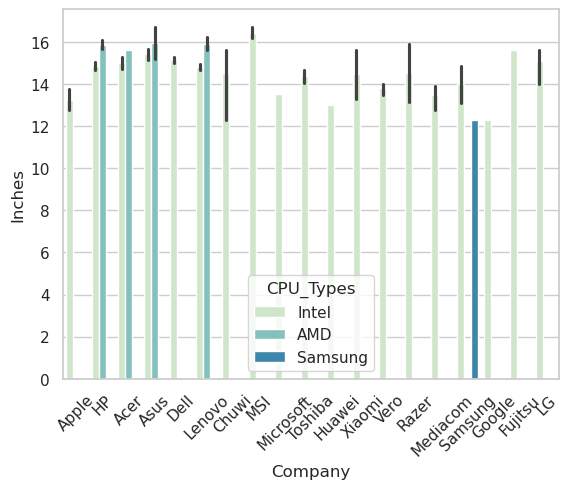

In [132]:
df['CPU_Types'] = df['Cpu'].apply(lambda x: 'Samsung' if 'Samsung' in x else ('Intel' if 'Intel' in x else ('AMD' if 'AMD' in x else 'Other')))
sns.barplot(x='Company', y='Inches', hue='CPU_Types', data=df, palette='GnBu')
plt.xticks(rotation=45)

In [133]:
df.head()

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,TouchScreen,IPS,HD_4K,CPU_Brand,GPU_Brand,Memory_Type,CPU_Frequency,Length,Width,PPI,CPU_Types
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,0,1,0,Intel,Intel,SSD,2.3,2560.0,1600.0,226.983005,Intel
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,0,0,0,Intel,Intel,Flash Storage,1.8,1440.0,900.0,127.677940,Intel
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636.0000,0,0,1,Intel,Intel,SSD,2.5,1920.0,1080.0,141.211998,Intel
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360,0,1,0,Intel,AMD,SSD,2.7,2880.0,1800.0,220.534624,Intel
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,0,1,0,Intel,Intel,SSD,3.1,2560.0,1600.0,226.983005,Intel


In [ ]:
OUTLIERS
DETECTING OUTLIERS

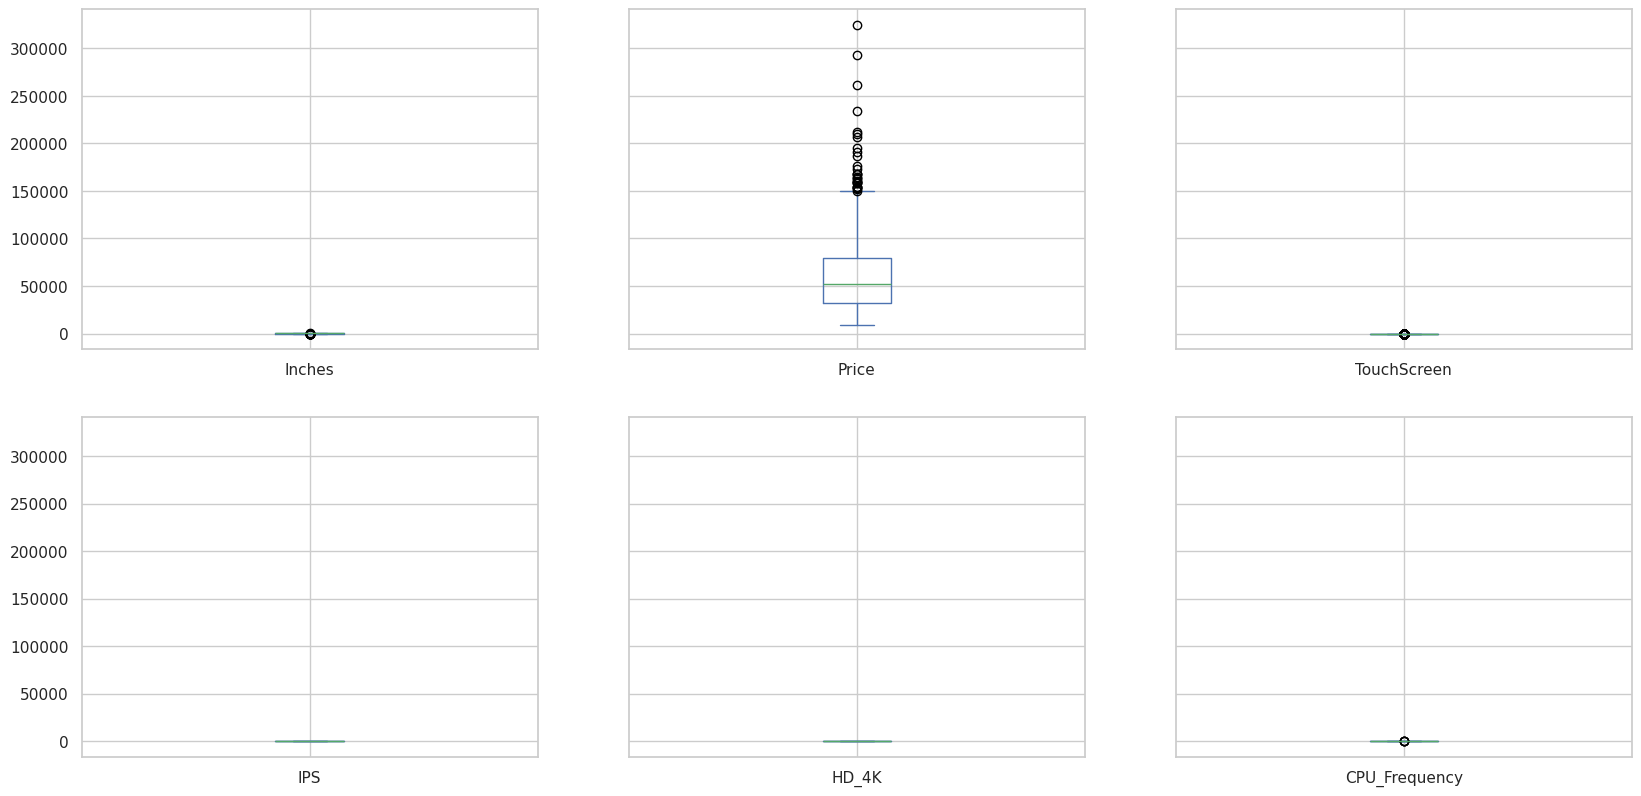

In [136]:
df_Original.select_dtypes ( np.number ).plot ( kind = 'box' , subplots = True , layout = ( 3 , 3 ) , figsize = ( 20 , 15 ) , sharex = True , sharey = True );